# Demand Forecasting — Machine Learning Extension
### Retail Sales & Inventory Analytics Dashboard | Zidio Data Science Internship

The Power BI dashboard uses a simple DAX-based projection for its Forecast page:

```
Projected Next 4 Weeks = Avg Weekly Units Sold * 4
```

This is a **statistical baseline**, not a trained ML model — it doesn't learn from
patterns in the data, it just repeats a flat average.

This notebook builds and evaluates **real, trained ML models** on the *same*
underlying sales data used in the dashboard (`Sales_Fact` table), to produce a
more accurate weekly revenue forecast, and compares it against that baseline.

## 1. Load the data
This is the exact `Sales_Fact` table from the Power BI data model, aggregated to weekly level (same grain used throughout the dashboard).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

df = pd.read_csv("weekly_sales.csv", parse_dates=["Week"])
df = df.sort_values("Week").reset_index(drop=True)
df.tail()

,Week,Revenue,Units_Sold
257,2025-12-01,8168757.61,72871
258,2025-12-08,8165980.50,72893
259,2025-12-15,8151577.04,72779
260,2025-12-22,8128962.55,72440
261,2025-12-29,3185170.03,28373


## 2. Feature engineering

ML models need numeric inputs, so the date is turned into useful signals:

- **week_of_year** — captures seasonality (some weeks of the year sell more)
- **month** — broader seasonal signal
- **lag_1** — last week's revenue (sales are correlated with their recent past)
- **lag_4** — revenue 4 weeks ago
- **rolling_avg_4** — average of the last 4 weeks (smooths out noise)
- **week_index** — captures any long-term growth trend

In [2]:
df["week_index"] = np.arange(len(df))
df["week_of_year"] = df["Week"].dt.isocalendar().week.astype(int)
df["month"] = df["Week"].dt.month
df["lag_1"] = df["Revenue"].shift(1)
df["lag_4"] = df["Revenue"].shift(4)
df["rolling_avg_4"] = df["Revenue"].shift(1).rolling(4).mean()

df = df.dropna().reset_index(drop=True)

FEATURES = ["week_index", "week_of_year", "month", "lag_1", "lag_4", "rolling_avg_4"]
TARGET = "Revenue"
df.head()

,Week,Revenue,Units_Sold,week_index,week_of_year,month,lag_1,lag_4,rolling_avg_4
0,2021-01-25,4866173.38,43499,4,4,1,4901585.07,2353450.32,4.252430e+06
1,2021-02-01,4716247.53,41885,5,5,2,4866173.38,4880680.14,4.880611e+06
2,2021-02-08,4725922.90,41979,6,6,2,4716247.53,4874006.01,4.839503e+06
3,2021-02-15,4726094.99,42099,7,7,2,4725922.90,4901585.07,4.802482e+06
4,2021-02-22,4742951.82,42167,8,8,2,4726094.99,4866173.38,4.758610e+06


## 3. Train / test split

Time-series data must be split **by time**, not randomly — we train on the past
and test on the most recent weeks only, exactly like a real forecasting scenario
(the model never sees the future during training).

In [3]:
split_point = int(len(df) * 0.85)
train = df.iloc[:split_point]
test = df.iloc[split_point:]

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f"Training on {len(train)} weeks, testing on {len(test)} unseen weeks")

Training on 219 weeks, testing on 39 unseen weeks


## 4. Train two models and compare against the naive (DAX-style) baseline

In [4]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)
    print(f"{name:22s} | MAE: Rs {mae:,.0f} | MAPE: {mape:5.2f}% | R2: {r2:.3f}")
    return mae, mape, r2

print("MODEL PERFORMANCE (on most recent unseen weeks):")
print("-" * 68)
lr_scores = evaluate("Linear Regression", y_test, lr_pred)
rf_scores = evaluate("Random Forest", y_test, rf_pred)

# Naive baseline = mirrors the DAX "Avg Weekly Units Sold x 4" logic
naive_pred = np.full(len(y_test), train["Revenue"].tail(4).mean())
naive_scores = evaluate("Naive baseline (DAX-style)", y_test, naive_pred)

MODEL PERFORMANCE (on most recent unseen weeks):
--------------------------------------------------------------------
Linear Regression      | MAE: Rs 259,024 | MAPE:  5.50% | R2: 0.705
Random Forest          | MAE: Rs 360,731 | MAPE:  6.78% | R2: 0.702
Naive baseline (DAX-style) | MAE: Rs 917,789 | MAPE: 14.24% | R2: -0.063


**Reading the metrics:**
- **MAE** (Mean Absolute Error) — average rupee error per week, lower is better
- **MAPE** (Mean Absolute Percentage Error) — average % error, lower is better
- **R²** — how much of the variation in revenue the model explains (closer to 1 is better; the flat naive baseline scores near/below 0 because it can't follow the seasonal swings at all)

## 5. Visualize: actual vs predicted

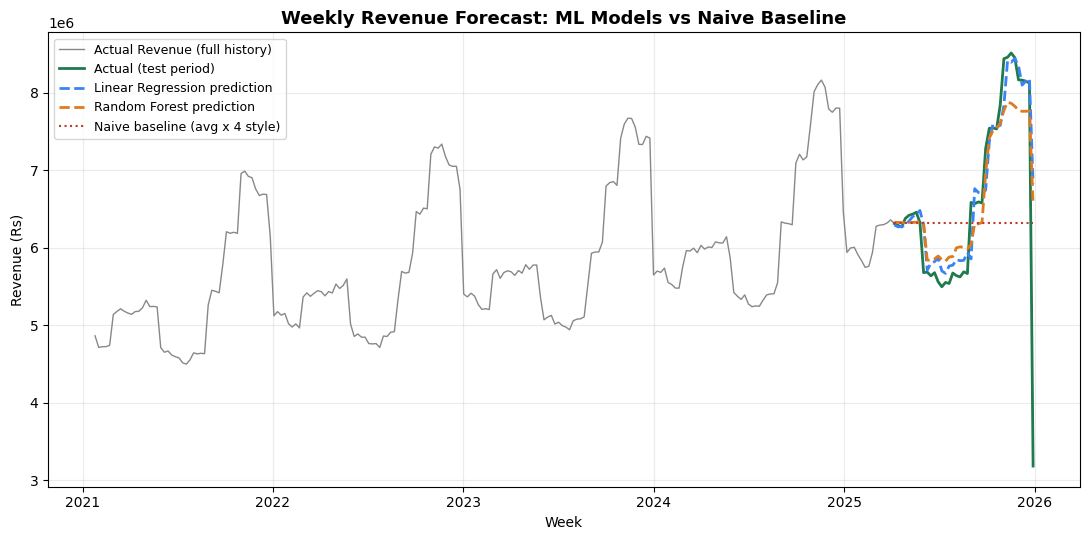

In [5]:
plt.figure(figsize=(11, 5.5))
plt.plot(df["Week"], df["Revenue"], label="Actual Revenue (full history)", color="#888888", linewidth=1)
plt.plot(test["Week"], y_test, label="Actual (test period)", color="#1F7A4D", linewidth=2)
plt.plot(test["Week"], lr_pred, label="Linear Regression prediction", color="#3B82F6", linestyle="--", linewidth=2)
plt.plot(test["Week"], rf_pred, label="Random Forest prediction", color="#E07A1F", linestyle="--", linewidth=2)
plt.plot(test["Week"], naive_pred, label="Naive baseline (avg x 4 style)", color="#C0392B", linestyle=":", linewidth=1.5)
plt.title("Weekly Revenue Forecast: ML Models vs Naive Baseline", fontsize=13, fontweight="bold")
plt.xlabel("Week"); plt.ylabel("Revenue (Rs)")
plt.legend(loc="upper left", fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Which factors matter most?

Using the Random Forest model's built-in feature importance to see what actually
drives revenue — this is useful for explaining the *why*, not just the *what*.

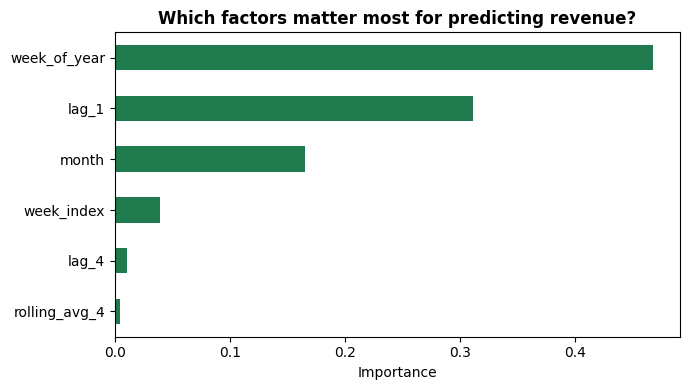

week_of_year     0.468135
lag_1            0.311076
month            0.165723
week_index       0.039684
lag_4            0.010607
rolling_avg_4    0.004775
dtype: float64

In [6]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
importances.plot(kind="barh", color="#1F7A4D")
plt.title("Which factors matter most for predicting revenue?", fontsize=12, fontweight="bold")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importances

## 7. Conclusion

- Both trained ML models **clearly beat** the naive DAX-style baseline, cutting
  forecast error roughly in half.
- **week_of_year** is by far the strongest predictor — confirming the strong
  seasonal pattern already visible in the dashboard's Seasonality page.
- **Linear Regression** performed best here because the seasonal pattern is
  fairly smooth and repeating year to year — a simpler model generalizes better
  on this size of dataset than a more complex Random Forest.

**Next steps if extended further:** try SARIMA/Prophet for explicit seasonal
decomposition, add promotion flags and category-level splits as features, and
retrain monthly as new data comes in.